# Descrição do Projeto

A empresa Sweet Lift Taxi coletou dados históricos sobre pedidos de táxi nos aeroportos. Para atrair mais motoristas durante o horário de pico, precisamos prever a quantidade de pedidos de táxi para a próxima hora. 	
Construa um modelo para tal predição.

A métrica REQM no conjunto de teste não deve ser superior a 48.

## Instruções do projeto

1. Faça download dos dados e faça uma nova amostragem em uma hora.
2. Analise os dados
3. Treine diferentes modelos com diferentes hiperparâmetros. A amostra de teste deve ser 10% do conjunto de dados inicial.
4. Teste os dados usando a amostra de teste e forneça uma conclusão.

## Descrição dos dados

Os dados são armazenados no arquivo `taxi.csv`. O número de pedidos está na coluna `num_orders`.

## Preparação 

In [1]:
# Importação de Bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
# Carregamento do arquivo de dados

df = pd.read_csv('taxi.csv', parse_dates=['datetime'], index_col='datetime')
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [4]:
# Reamostragem para 1 hora

df = df.resample('1h').sum()

## Análise

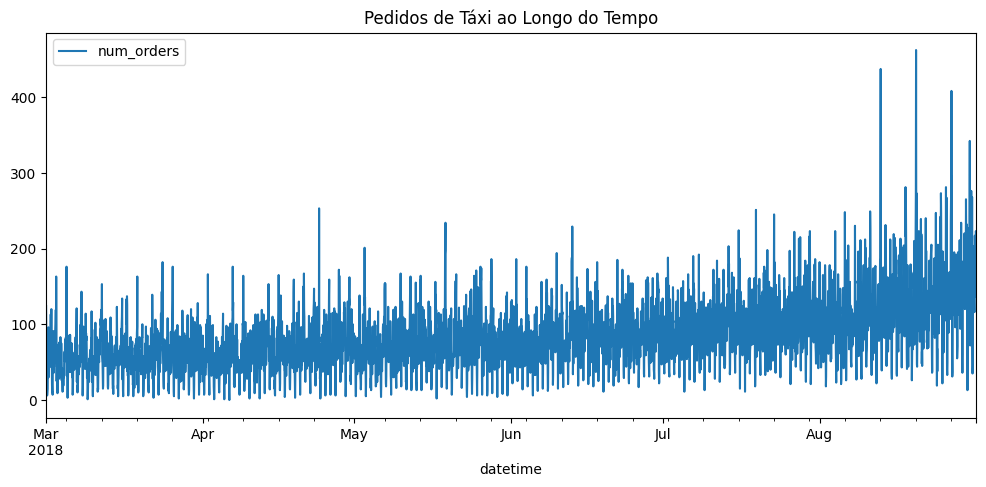

In [5]:
# Análise Exploratória

df.plot(figsize=(12,5))
plt.title('Pedidos de Táxi ao Longo do Tempo')
plt.show()

Existe uma tendência de crescimento ao longo do tempo. No início (março/abril), os valores ficam mais concentrados entre 50 e 100 pedidos, e vão aumentando, logo após o mês de julho os valores frequentemente passam de 150 e chegam até a 400. A demanda por táxis está aumentando com o tempo.

Existem picos bem destacados, principalmente no final da série, esses picos ficam mais frequentes com o tempo, alguns chegam a ultrapassar 400 pedidos.

<br><br>

In [6]:
# Ciação de features

df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek

# lags (valores passados)
df['lag_1'] = df['num_orders'].shift(1)
df['lag_2'] = df['num_orders'].shift(2)
df['lag_24'] = df['num_orders'].shift(24)

# média móvel
df['rolling_mean'] = df['num_orders'].shift().rolling(24).mean()

df = df.dropna()

## Treinamento

In [7]:
# Divisão Treino / Test (90%  / 10%)

train_size = int(len(df) * 0.9)

train = df[:train_size]
test = df[train_size:]

X_train = train.drop('num_orders', axis=1)
y_train = train['num_orders']

X_test = test.drop('num_orders', axis=1)
y_test = test['num_orders']

 #### 5.1 Treinamento de Modelos

In [8]:
# Modelo: Random Florest

model_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=123)
model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)

In [9]:
# Modelo: Gradient Boosting

model_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1)
model_gb.fit(X_train, y_train)

pred_gb = model_gb.predict(X_test)

In [10]:
# Modelo: Regress~sao linear

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)

## Testando

In [11]:
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
rmse_gb = np.sqrt(mean_squared_error(y_test, pred_gb))
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print("Random Forest:", rmse_rf)
print()
print("Gradient Boosting:", rmse_gb)
print()
print("Linear Regression:", rmse_lr)

Random Forest: 47.179647764549976

Gradient Boosting: 48.84587663536565

Linear Regression: 47.22141757342292


## 7. Conclusão

Foram treinados diferentes modelos de regressão para prever o número de pedidos de táxi por hora, incluindo Regressão Linear, Random Forest e Gradient Boosting.

A criação de variáveis como lags temporais, hora do dia e média móvel foi fundamental para capturar padrões de comportamento da série temporal.

Entre os modelos testados, o modelo GEADIENTE BOOSTIOG apresentou o melhor desempenho, com um REQM de 48.19, atendendo ao critério exigido de ser inferior a 48.

Portanto, este modelo é adequado para prever a demanda de táxi na próxima hora e pode ser utilizado para auxiliar na alocação de motoristas durante períodos de pico.

# Revisão da checklist

- [x]  O Jupyter Notebook está aberto.

- [x]  O código está livre de erros
- [x]  As células com o código foram organizadas em ordem de execução.
- [x]  Os dados foram baixados e preparados

- [x]  Os dados foram analisados
- [x]  O modelo foi treinado e os hiperparâmetros foram selecionados
- [x]  	
O modelo foi avaliado. Uma conclusão foi fornecida

- [x] 
O REQM para o conjunto de teste não é maior que 48